In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('/content/flixpatrol.csv')
display(df.head())
print(df.info())
print(df.isnull().sum())
df['Premiere']=pd.to_numeric(df['Premiere']).astype('Int64')
df['Watchtime in Million']=df['Watchtime in Million'].str.replace('M','').astype(float)
display(df.head())


,Rank,Title,Type,Premiere,Genre,Watchtime,Watchtime in Million
0,1,The Night Agent,TV Show,2023.0,Action,"81,21,00,000",812.1M
1,2,Ginny & Georgia,TV Show,2021.0,Drama,"66,51,00,000",665.1M
2,3,The Glory,TV Show,2022.0,Thriller,"62,28,00,000",622.8M
3,4,Wednesday,TV Show,2022.0,Fantasy,"50,77,00,000",507.7M
4,5,Queen Charlotte: A Bridgerton Story,TV Show,2023.0,Drama,"50,30,00,000",503.0M


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18164 entries, 0 to 18163
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Rank                  18164 non-null  int64  
 1   Title                 18164 non-null  object 
 2   Type                  18164 non-null  object 
 3   Premiere              18030 non-null  float64
 4   Genre                 17984 non-null  object 
 5   Watchtime             18164 non-null  object 
 6   Watchtime in Million  18164 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 993.5+ KB
None
Rank                      0
Title                     0
Type                      0
Premiere                134
Genre                   180
Watchtime                 0
Watchtime in Million      0
dtype: int64


,Rank,Title,Type,Premiere,Genre,Watchtime,Watchtime in Million
0,1,The Night Agent,TV Show,2023,Action,"81,21,00,000",812.1
1,2,Ginny & Georgia,TV Show,2021,Drama,"66,51,00,000",665.1
2,3,The Glory,TV Show,2022,Thriller,"62,28,00,000",622.8
3,4,Wednesday,TV Show,2022,Fantasy,"50,77,00,000",507.7
4,5,Queen Charlotte: A Bridgerton Story,TV Show,2023,Drama,"50,30,00,000",503.0


Recommendation for Customer_A:


,Title
0,Once Upon a Time… in Hollywood
1,Next Day Air
2,The Alleys
3,Esterno Notte
4,A History of Violence
...,...
447,Mafia Inc.
448,Yuma
449,Perfect Number
450,Gold Coast Lounge


Recommendation for Customer_B:


,Title
0,Beecham House
1,Victorious Mehmets
2,Frontier
3,Arthdal Chronicles
4,Ashes of Love
...,...
77,Knightfall
78,The Queen and the Conqueror
79,My Country: The New Age
80,Taboo


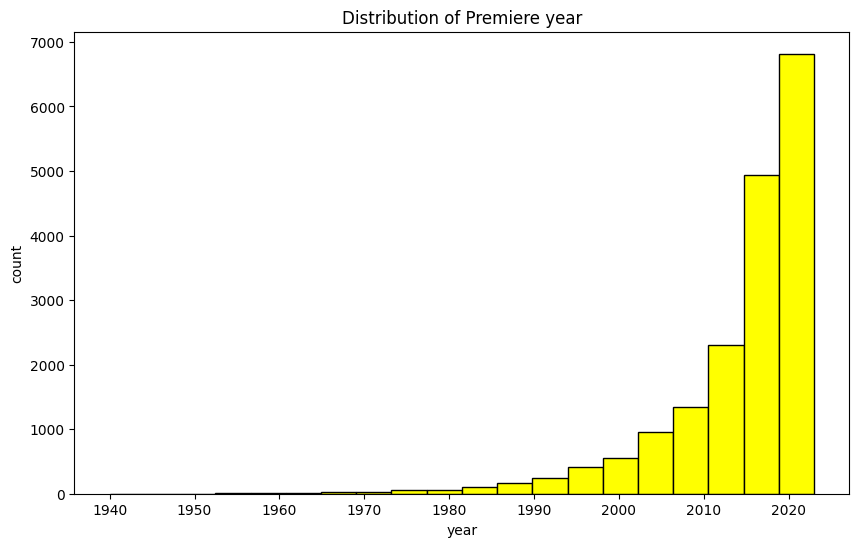

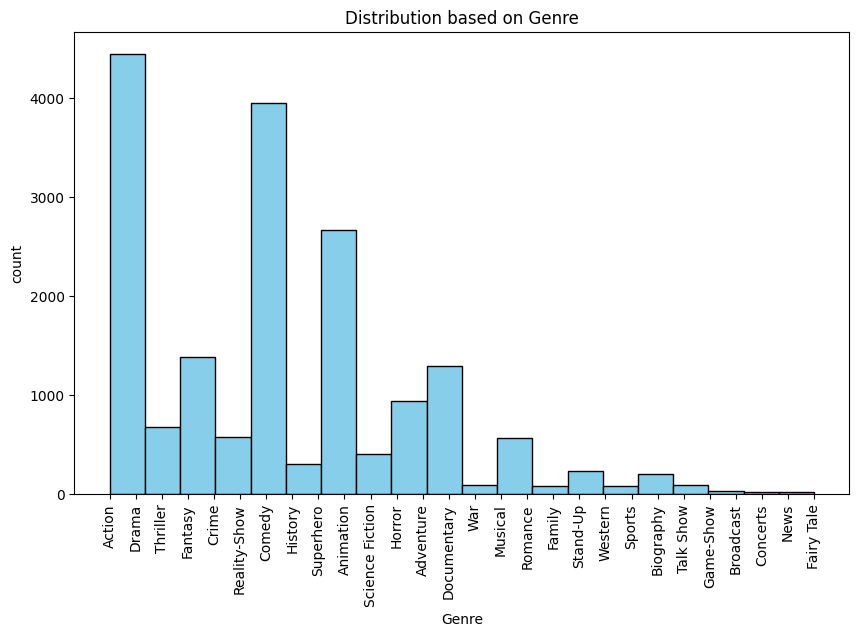

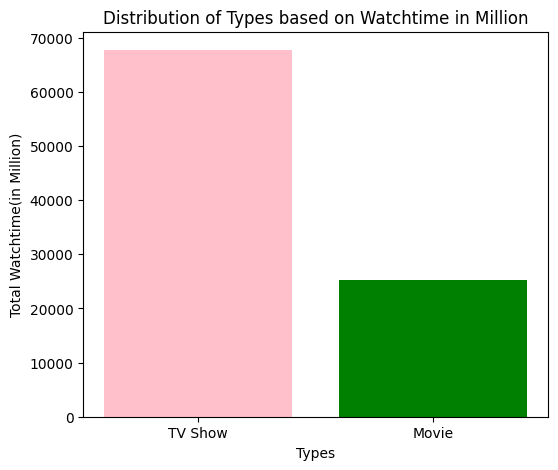

In [ ]:
#Netflix_Project:Task_1

# Recommendation for Customer_A
customer_A=df[(df['Type']=='Movie') & (df['Genre']=='Crime') & (df['Premiere'].between(2003,2023))].sort_values(by='Watchtime',ascending=False)['Title']
print('Recommendation for Customer_A:')
display(customer_A.reset_index(drop=True))

# Recommendation for Customer_B
customer_B=df[(df['Type']=='TV Show') & (df['Genre']=='History') & (df['Premiere'].between(2010,2020))].sort_values(by='Watchtime',ascending=True)['Title']
print('Recommendation for Customer_B:')
display(customer_B.reset_index(drop=True))

# Histogram based on Premiere(year)
plt.figure(figsize=(10,6))
plt.hist(df['Premiere'].dropna(),bins=20,color='yellow',edgecolor='black')
plt.title('Distribution of Premiere year')
plt.xlabel('year')
plt.xticks(range(1940,2025,10))
plt.ylabel('count')
plt.show()

# Histogram based on Genre
plt.figure(figsize=(10,6))
plt.hist(df['Genre'].dropna(),bins=20,color='skyblue',edgecolor='black')
plt.title('Distribution based on Genre')
plt.xlabel('Genre')
plt.xticks(rotation=90)
plt.ylabel('count')
plt.show()

# Histogram based on Views
plt.figure(figsize=(6,5))
bar_data=df.groupby('Type')['Watchtime in Million'].sum().sort_values(ascending=False)
plt.bar(bar_data.index,bar_data.values,color=['pink','green'])
plt.title('Distribution of Types based on Watchtime in Million')
plt.xlabel('Types')
plt.ylabel('Total Watchtime(in Million)')
plt.show()


In [ ]:
#Netflix_Project:Task_2

user_type=input('Enter your Type(Movie/TV Show):')
user_genre=input('Enter your Genre:')
start_year=int(input('Enter the starting year:'))
end_year=int(input('Enter the ending year:'))
min_views=float(input('Enter the Minimum number of Views(in Million):'))

user_data=df[(df['Type']==user_type) & (df['Genre']==user_genre) & (df['Premiere'].between(start_year,end_year)) & (df['Watchtime in Million']>=min_views)]

if(len(user_data)>0):
    suggestion=user_data.sort_values(by='Watchtime in Million', ascending=False)
    print(f"\nRecommended {user_type}:")
    display(suggestion['Title'].reset_index(drop=True))
else:
    print(f"No matching {user_type} found.")

Enter your Type(Movie/TV Show):TV Show
Enter your Genre:Drama
Enter the starting year:2015
Enter the ending year:2023
Enter the Minimum number of Views(in Million):500

Recommended TV Show:


,Title
0,Ginny & Georgia
1,Queen Charlotte: A Bridgerton Story



Total Watchtime by Genre:


,Watchtime in Million
Genre,
Drama,19344.6
Comedy,14725.7
Animation,14578.9
Crime,9242.9
Action,6258.6
Thriller,4812.7
Fantasy,3607.0
Reality-Show,3507.0
Documentary,3313.8



Total Watchtime by Types and Genre:


Type     Genre          
Movie    Action              3293.6
         Adventure            981.1
         Animation           3363.5
         Biography            273.1
         Comedy              4570.2
         Concerts              11.7
         Crime               1976.0
         Documentary          660.6
         Drama               2622.4
         Fairy Tale             2.0
         Family                89.7
         Fantasy              673.5
         History              231.0
         Horror              1229.1
         Musical              189.4
         Reality-Show           0.4
         Romance             1044.6
         Science Fiction     1232.4
         Sports                71.1
         Stand-Up             231.1
         Superhero            301.8
         Thriller            1733.9
         War                  359.6
         Western              107.0
TV Show  Action              2965.0
         Adventure              1.4
         Animation          11215.4
         Biography              0.4
         Broadcast             16.4
         Comedy             10155.5
         Crime               7266.9
         Documentary         2653.2
         Drama              16722.2
         Family               132.2
         Fantasy             2933.5
         Game-Show             13.3
         History             1896.1
         Horror              1314.2
         News                   1.4
         Reality-Show        3506.6
         Romance                1.7
         Science Fiction     1656.7
         Superhero           1843.0
         Talk Show             68.7
         Thriller            3078.8
         War                   97.4
         Western               44.3
Name: Watchtime in Million, dtype: float64


Watchtime by Release Year:


...

,Watchtime in Million
Type,
Movie,25279.5
TV Show,67707.9



Top 10 Most Watched Titles:


,Title,Type,Genre,Premiere,Watchtime in Million
0,The Night Agent,TV Show,Action,2023,812.1
1,Ginny & Georgia,TV Show,Drama,2021,665.1
2,The Glory,TV Show,Thriller,2022,622.8
3,Wednesday,TV Show,Fantasy,2022,507.7
4,Queen Charlotte: A Bridgerton Story,TV Show,Drama,2023,503.0
5,You,TV Show,Crime,2018,440.6
6,La Reina del Sur,TV Show,Drama,2011,429.6
7,Outer Banks,TV Show,Drama,2020,402.5
8,Ginny & Georgia,TV Show,Drama,2021,302.1
9,FUBAR,TV Show,Action,2023,266.2




Recommendation and Complaints analysis chart:


Type,Movie,TV Show
Genre,,
Action,3293.6,2965.0
Adventure,981.1,1.4
Animation,3363.5,11215.4
Biography,273.1,0.4
Broadcast,NaN,16.4
Comedy,4570.2,10155.5
Concerts,11.7,NaN
Crime,1976.0,7266.9
Documentary,660.6,2653.2


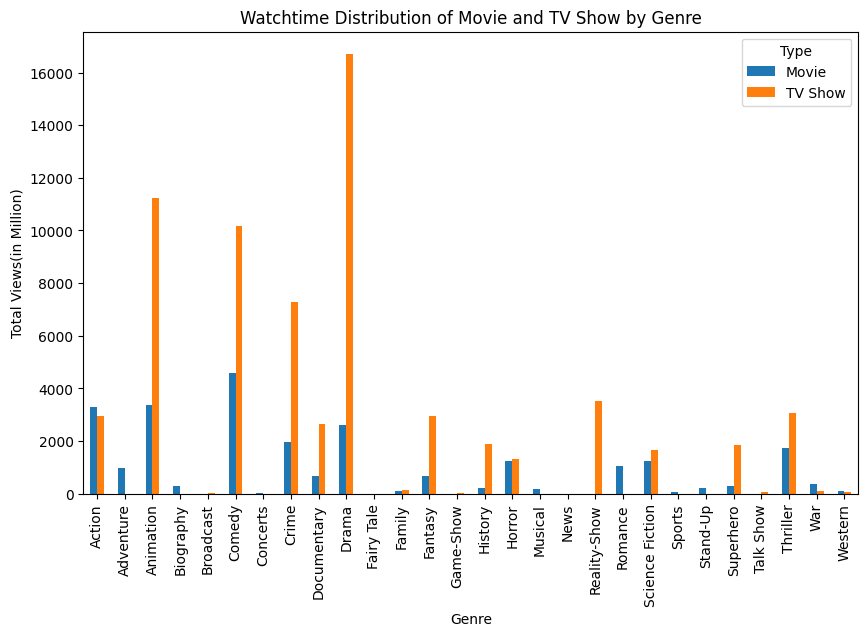


Netflix Recommendation:
Purchase movies in genres: ['Action', 'Animation', 'Comedy', 'Crime', 'Drama', 'Horror', 'Science Fiction', 'Thriller']
Invest in TV shows in genres: ['Action', 'Animation', 'Comedy', 'Crime', 'Drama', 'Reality-Show', 'Thriller']

Customer Feedback:
Add more movies in genres: ['Adventure', 'Biography', 'Concerts', 'Documentary', 'Fairy Tale', 'Family', 'Fantasy', 'History', 'Musical', 'Reality-Show', 'Romance', 'Sports', 'Stand-Up', 'Superhero', 'War', 'Western']
Add more TV shows in genres: ['Adventure', 'Biography', 'Broadcast', 'Documentary', 'Family', 'Fantasy', 'Game-Show', 'History', 'Horror', 'News', 'Romance', 'Science Fiction', 'Superhero', 'Talk Show', 'War', 'Western']


In [ ]:
#Netflix_Project:Task_3

# 1)Grouped by Genre using Watchingtime in Million
genre_watchtime=df.groupby('Genre')['Watchtime in Million'].sum().sort_values(ascending=False)
print("\nTotal Watchtime by Genre:")
display(genre_watchtime)

# 2)Grouped by Genre and Movie/TV show using Watchingtime in Million
type_genre=df.groupby(['Type','Genre'])['Watchtime in Million'].sum()
print('\nTotal Watchtime by Types and Genre:')
display(type_genre)

# 3)Grouped by Premiere(Year) using Watchingtime in Million
year_watchtime=df.groupby('Premiere')['Watchtime in Million'].sum().sort_values(ascending=False)
print("\nWatchtime by Release Year:")
display(year_watchtime)

#4)which one have the best View time Movie or TV show
type_watchtime=df.groupby('Type')['Watchtime in Million'].sum()
print("\nTotal Watchtime by Type:")
display(type_watchtime)

# 5)Top 10 Movies/TV show
top_titles=df.sort_values(by='Watchtime in Million', ascending=False).head(10)
print("\nTop 10 Most Watched Titles:")
display(top_titles[['Title','Type','Genre','Premiere','Watchtime in Million']])

# Recommendation and Complaints using Bar-chart
print('\n\nRecommendation and Complaints analysis chart:')
bar_data=df.groupby(['Genre','Type'])['Watchtime in Million'].sum().unstack()
display(bar_data)
bar_data.plot(kind='bar', figsize=(10,6))
plt.title("Watchtime Distribution of Movie and TV Show by Genre")
plt.xlabel('Genre')
plt.ylabel('Total Views(in Million)')
plt.show()

# Netflix employee recommendation:
top_movie_genres=bar_data[bar_data['Movie']>bar_data['Movie'].mean()].index.tolist()
top_tv_genres=bar_data[bar_data['TV Show']>bar_data['TV Show'].mean()].index.tolist()
print("\nNetflix Recommendation:")
print("Purchase movies in genres:", top_movie_genres)
print("Invest in TV shows in genres:", top_tv_genres)

# Netflix customer complaints/Feedback:
low_movie_genres=bar_data[bar_data['Movie']<bar_data['Movie'].mean()].index.tolist()
low_tv_genres=bar_data[bar_data['TV Show']<bar_data['TV Show'].mean()].index.tolist()
print("\nCustomer Feedback:")
print("Add more movies in genres:",low_movie_genres)
print("Add more TV shows in genres:",low_tv_genres)

In [ ]:
# NetflixDataset-Project:Task_1
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
with zipfile.ZipFile('NetFlixDataSet.zip', 'r') as files:
    files.extractall()

data=pd.DataFrame()
file_names=files.namelist()
for name in file_names:
  df=pd.read_csv(name)
  data=pd.concat([data,df],ignore_index=True)
display(data)
data.info()
data['imdb_rating']=data['imdb_rating'].str.replace('%', '').astype(float)
data['rt_rating']=data['rt_rating'].str.replace('%', '').astype(float)
data['release_date']=pd.to_datetime(data['release_date'],errors='coerce')
data=data.drop_duplicates()

print('\nFilter movies with IMDB rating>75%')
high_imdb_movies=data[(data['show_type']=='Movie') & (data['imdb_rating'] > 75)]['title']
display(high_imdb_movies.reset_index(drop=True))

print('\nFilter movies with IMDB rating>60% and RT rating<=50%')
filter=data[(data['show_type']=='TV Show') &
    (data['is_NF_Ori']==True) &
    (data['imdb_rating']>60) &
    (data['rt_rating']>=50) &
    (data['ori_country'].isin(['Germany','USA','India'])) &
    (data['release_date'].dt.month>=7)]['title']
display(filter.reset_index(drop=True))



,week,show_type,title,ori_country,genre,release_date,is_NF_Ori,imdb_rating,rt_rating,country_chart,show_link,Continent,Continent/the-letter-for-the-king-2020,EUR,rel_yr,rel_mt
0,37,Movie,#Alive,South Korea,Horror,2020-09-08,False,62%,86%,ARE,https://flixpatrol.com/title/alive-2020,ASI,NaN,NaN,NaN,NaN
1,37,TV Show,Away,USA,Science Fiction,2020-09-04,True,71%,73%,ARE,https://flixpatrol.com/title/away-2020,ASI,NaN,NaN,NaN,NaN
2,36,Movie,Skyscraper,USA,Action,2018-07-04,False,61%,48%,ARE,https://flixpatrol.com/title/skyscraper,ASI,NaN,NaN,NaN,NaN
3,36,TV Show,Lucifer,USA,Superhero,2016-01-25,True,83%,87%,ARE,https://flixpatrol.com/title/lucifer,ASI,NaN,NaN,NaN,NaN
4,35,Movie,Project Power,USA,Action,2020-08-14,True,61%,63%,ARE,https://flixpatrol.com/title/project-power,ASI,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6051,16,TV Show,Money Heist,Spain,Action,2017-05-02,True,84%,93%,ZAF,https://flixpatrol.com/title/money-heist,AFR,NaN,NaN,NaN,NaN
6052,15,Movie,Fifty Shades Freed,USA,Romance,2018-02-07,False,34%,12%,ZAF,https://flixpatrol.com/title/fifty-shades-freed,AFR,NaN,NaN,NaN,NaN
6053,15,TV Show,Money Heist,Spain,Action,2017-05-02,True,84%,93%,ZAF,https://flixpatrol.com/title/money-heist,AFR,NaN,NaN,NaN,NaN
6054,14,Movie,Coffee & Kareem,USA,Comedy,2020-04-03,True,50%,19%,ZAF,https://flixpatrol.com/title/coffee-kareem,AFR,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6056 entries, 0 to 6055
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   week                                    6056 non-null   int64  
 1   show_type                               6056 non-null   object 
 2   title                                   6056 non-null   object 
 3   ori_country                             5993 non-null   object 
 4   genre                                   5947 non-null   object 
 5   release_date                            6056 non-null   object 
 6   is_NF_Ori                               6056 non-null   bool   
 7   imdb_rating                             5906 non-null   object 
 8   rt_rating                               5069 non-null   object 
 9   country_chart                           6056 non-null   object 
 10  show_link                               6056 non-null   obje

,title
0,Wonder
1,Wonder
2,The Old Guard
3,Doctor Sleep
4,The Old Guard
...,...
205,Catch Me If You Can
206,The Old Guard
207,The Old Guard
208,Eurovision Song Contest: The Story of Fire Saga



Filter movies with IMDB rating>60% and RT rating<=50%


,title
0,Away
1,Dark
2,Dark
3,The Sinner
4,Away
...,...
145,Dark
146,Dark
147,Dark
148,Away


In [ ]:
# NetflixDataset-Project:Task_2

country=input("Enter country:")
genre=input("Enter genre:")
min_imdb=float(input("Enter minimum IMDB rating (0-100):"))
release_month=int(input("Enter release month (1-12):"))
show_type=input("Enter show type (Movie/TV Show):")

suggestions=data[
    (data['ori_country']==country) &
    (data['genre']==genre) &
    (data['imdb_rating']>=min_imdb) &
    (data['release_date'].dt.month==release_month) &
    (data['show_type']==show_type)]

if len(suggestions)>0:
    print('Suggested Movie list:')
    suggestions=suggestions.drop_duplicates(subset='title')
    display(suggestions['title'].reset_index(drop=True))
else:
    print("No matches found based on your criteria.")

# Another 10 Problems
# 1)Movies with IMDB rating<mean(IMDB)
p1=data[(data['show_type']=='Movie') & (data['imdb_rating']<data['imdb_rating'].mean())]
print("\nMovies with IMDb<mean(IMDB):")
display(p1['title'].drop_duplicates().reset_index(drop=True))

# 2)TV shows with RT rating<mean(RT)
p2=data[(data['show_type']=='TV Show') & (data['rt_rating']<data['rt_rating'].mean())]
print("\nMovies with RT<mean(RT):")
display(p2['title'].drop_duplicates().reset_index(drop=True))

# 3)Count of Netflix Originals
p3=data[data['is_NF_Ori']==True].shape[0]
print("\nNumber of Netflix Originals:",p3)

# 4)Movies released in 2020
p4=data[(data['show_type']=='Movie') & (data['release_date'].dt.year==2020)]
print("\nMovies released in 2020:")
display(p4['title'].drop_duplicates().reset_index(drop=True))

# 5)Shows from USA
p5=data[data['ori_country']=='USA']
print("\nTitles from USA:")
display(p5['title'].drop_duplicates().reset_index(drop=True))

# 6)Action genre titles
p6=data[data['genre']=='Action']
print("\nAction Genre Titles:")
display(p6['title'].drop_duplicates().reset_index(drop=True))

# 7)Titles released in July
p7= data[data['release_date'].dt.month==7]
print("\nTitles released in July:")
display(p7['title'].drop_duplicates().reset_index(drop=True))

# 8)Top 10 highest-rated movies by IMDb
p8=data[data['show_type']=='Movie'].sort_values('imdb_rating', ascending=False)
print("\nTop 10 highest-rated movies by IMDb:")
display(p8['title'].drop_duplicates().head(10).reset_index(drop=True))

# 9)Count of TV shows vs Movies
p9=data['show_type'].value_counts()
print("\nCount of TV Shows vs Movies:")
display(p9)

# 10)Titles from India
p10=data[data['ori_country']=='India']
print("\nTitles from India:")
display(p10['title'].drop_duplicates().reset_index(drop=True))

Enter country:USA
Enter genre:Action
Enter minimum IMDB rating (0-100):30
Enter release month (1-12):7
Enter show type (Movie/TV Show):Movie
Suggested Movie list:


,title
0,Skyscraper
1,Mission: Impossible - Fallout
2,The Equalizer 2
3,Death Wish



Movies with IMDb<mean(IMDB):


,title
0,#Alive
1,Skyscraper
2,Project Power
3,The Emoji Movie
4,The Crimes That Bind
...,...
150,The Frozen Ground
151,Blood Father
152,Wasp Network
153,Black and Blue



Movies with RT<mean(RT):


...

,title
0,Joker
1,I'm Thinking of Ending Things
2,The Pocket Hercules Naim
3,Deadpool 2
4,Miracle in Cell No. 7
5,The Old Guard
6,Get Out
7,Howls Moving Castle
8,Mad Max: Fury Road
9,John Wick: Chapter 3 – Parabellum



Count of TV Shows vs Movies:


,count
show_type,
Movie,2955
TV Show,2768
Documentary TV,260
Documentary,56
Movie -- --,11
Short,6



Titles from India:


,title
0,Masaba Masaba
1,Class of '83
2,Gunjan Saxena: The Kargil Girl
3,Raat Akeli Hai
4,Penalty
5,Bulbbul
6,Malang
7,Betaal
8,Love Aaj Kal


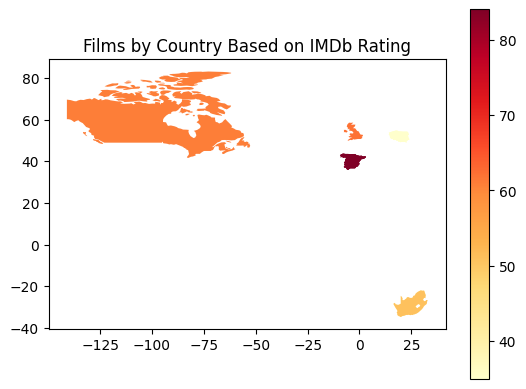

In [ ]:
# NetflixDataset-Project:Task_3

import geopandas as gpd
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
task=world.merge(df, left_on='NAME', right_on='ori_country', how='left')
task['imdb_rating']=task['imdb_rating'].str.replace('%','').astype(float)
task.plot(column='imdb_rating',cmap='YlOrRd',legend=True)
plt.title("Films by Country Based on IMDb Rating")
plt.show()